## Creating a Decision Tree Classification Model
---

### Discovery

Our task is to explore energy sources and their impact on **CARBON_INTENSITY**. We will explore the distribution of carbon intensity values, define thresholds for three distinct classes — **HIGH**, **MID**, and **LOW** — and use a Decision Tree classifier to determine whether our energy mix can predict which category we land in.

The three outcome classes are defined as:
- **HIGH**: Carbon intensity >= 275 gCO2/kWh
- **LOW**: Carbon intensity <= 152 gCO2/kWh (100 below the median of ~252)
- **MID**: Carbon intensity between 152 and 275 gCO2/kWh (not inclusive)

First we will import the required modules. They are:
- `pandas` — data manipulation
- `numpy` — numerical operations
- `seaborn` and `matplotlib.pyplot` — visualisation
- `sklearn.model_selection` — `train_test_split`
- `sklearn.tree` — `DecisionTreeClassifier`, `plot_tree`, `export_text`
- `sklearn.metrics` — `classification_report`, `confusion_matrix`, `accuracy_score`, `roc_auc_score`, `ConfusionMatrixDisplay`
- `sklearn.preprocessing` — `label_binarize`

In [1]:
# Import required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

---
### Data Preparation
We are importing our data, exploring the row counts, columns and data types. Decision Trees can handle continuous, discrete or binary input variables. We will restrict our dataset to the energy source columns and the target variable.

In [2]:
# Import the dataset and set the datetime as the index
df = pd.read_csv("df_fuel_ckan.csv", index_col="DATETIME", parse_dates=True)
df.head()

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
DATETIME,,,,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246.0,2518.0,0.0,0.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245.0,2495.0,0.0,0.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246.0,2465.0,0.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246.0,2439.0,0.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246.0,2363.0,0.0,0.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 33 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   WIND_EMB          305103 non-null  float64
 5   HYDRO             305103 non-null  float64
 6   IMPORTS           305103 non-null  float64
 7   BIOMASS           305103 non-null  float64
 8   OTHER             305103 non-null  float64
 9   SOLAR             305103 non-null  float64
 10  STORAGE           305103 non-null  float64
 11  GENERATION        305103 non-null  float64
 12  CARBON_INTENSITY  305103 non-null  float64
 13  LOW_CARBON        305103 non-null  float64
 14  ZERO_CARBON       305103 non-null  float64
 15  RENEWABLE         305103 non-null 

Restrict the dataset to only the required input features and the target variable.

In [5]:
# Restrict to required columns
df = df[["GAS", "COAL", "HYDRO", "WIND", "SOLAR", "NUCLEAR", "BIOMASS", "CARBON_INTENSITY"]]
df.head()

,GAS,COAL,HYDRO,WIND,SOLAR,NUCLEAR,BIOMASS,CARBON_INTENSITY
DATETIME,,,,,,,,
2009-01-01 00:00:00,8367.0,15037.0,246.0,248.0,0.0,7099.0,0.0,524.0
2009-01-01 00:30:00,8495.0,15095.0,245.0,229.0,0.0,7088.0,0.0,526.0
2009-01-01 01:00:00,8471.0,15088.0,246.0,207.0,0.0,7074.0,0.0,527.0
2009-01-01 01:30:00,8318.0,15035.0,246.0,191.0,0.0,7064.0,0.0,527.0
2009-01-01 02:00:00,8295.0,15005.0,246.0,175.0,0.0,7052.0,0.0,528.0


In [8]:
# Final check on data types, columns and row counts
df.info()
print(f"\nMissing values:\n{df.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   HYDRO             305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   SOLAR             305103 non-null  float64
 5   NUCLEAR           305103 non-null  float64
 6   BIOMASS           305103 non-null  float64
 7   CARBON_INTENSITY  305103 non-null  float64
dtypes: float64(8)
memory usage: 20.9 MB

Missing values:
GAS                 0
COAL                0
HYDRO               0
WIND                0
SOLAR               0
NUCLEAR             0
BIOMASS             0
CARBON_INTENSITY    0
dtype: int64


---
### Model Planning
Before building the model, we explore the distribution of our target variable. This helps us understand where our thresholds sit within the data, and whether our three classes are reasonably balanced.

In [9]:
# Get the mean and median carbon intensity to understand the averages and how our data may be skewed. 
mean_ci = df["CARBON_INTENSITY"].mean()
med_ci = df["CARBON_INTENSITY"].median()
print(f"The mean is {mean_ci:.1f} and the median is {med_ci:.1f} gCO2/kWh.")

The mean is 288.2 and the median is 252.0 gCO2/kWh.


Next we create a histogram to understand the distribution of carbon intensity, and visualise where our two thresholds sit.

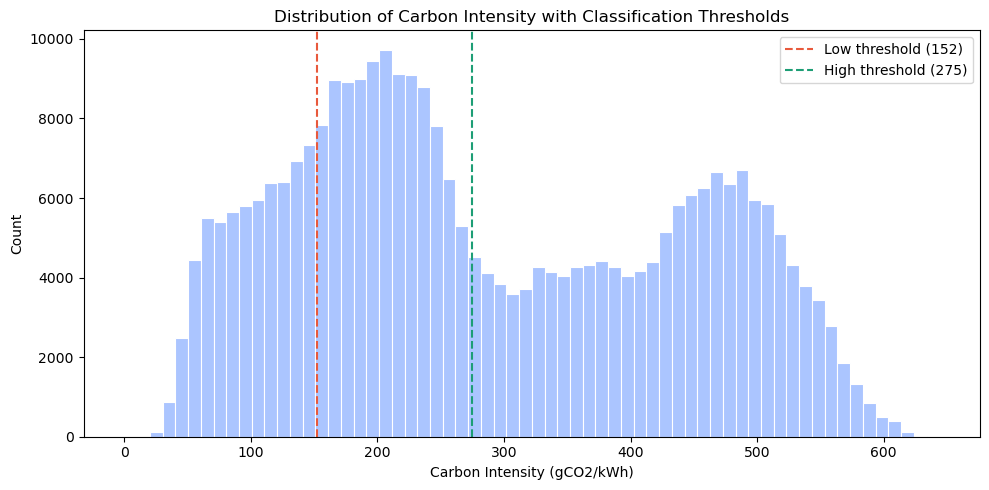

In [11]:
# Histogram of CARBON_INTENSITY with threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(x="CARBON_INTENSITY", data=df, color="#8FB2FF",
             edgecolor="white",
             binrange=(0, df["CARBON_INTENSITY"].max()),
             binwidth=10, ax=ax)

ax.axvline(x=152, color="#E8593C", linestyle="--", linewidth=1.5, label="Low threshold (152)")
ax.axvline(x=275, color="#1D9E75", linestyle="--", linewidth=1.5, label="High threshold (275)")

ax.set_title("Distribution of Carbon Intensity with Classification Thresholds")
ax.set_xlabel("Carbon Intensity (gCO2/kWh)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

Now we create the **target variable** — a three-class label based on the thresholds defined above.

In [17]:
# Create the three-class target variable
def classify_carbon(val):
    if val >= 275:
        return "HIGH"
    elif val <= 152:
        return "LOW"
    else:
        return "MID"

df["CARBON_CLASS"] = df["CARBON_INTENSITY"].apply(classify_carbon)
df[["CARBON_INTENSITY", "CARBON_CLASS"]].head(10)

,CARBON_INTENSITY,CARBON_CLASS
DATETIME,,
2009-01-01 00:00:00,524.0,HIGH
2009-01-01 00:30:00,526.0,HIGH
2009-01-01 01:00:00,527.0,HIGH
2009-01-01 01:30:00,527.0,HIGH
2009-01-01 02:00:00,528.0,HIGH
2009-01-01 02:30:00,529.0,HIGH
2009-01-01 03:00:00,531.0,HIGH
2009-01-01 03:30:00,531.0,HIGH
2009-01-01 04:00:00,534.0,HIGH


In [18]:
# Validate the class distribution
class_counts = df["CARBON_CLASS"].value_counts()
print(class_counts)
print(f"\nClass balance (%):")
print(df["CARBON_CLASS"].value_counts(normalize=True).mul(100).round(1))

CARBON_CLASS
HIGH    139851
MID     100407
LOW      64845
Name: count, dtype: int64

Class balance (%):
CARBON_CLASS
HIGH    45.8
MID     32.9
LOW     21.3
Name: proportion, dtype: float64


A correlation matrix will help us understand the relationship between each input variable and carbon intensity, and identify any intercorrelation between features.

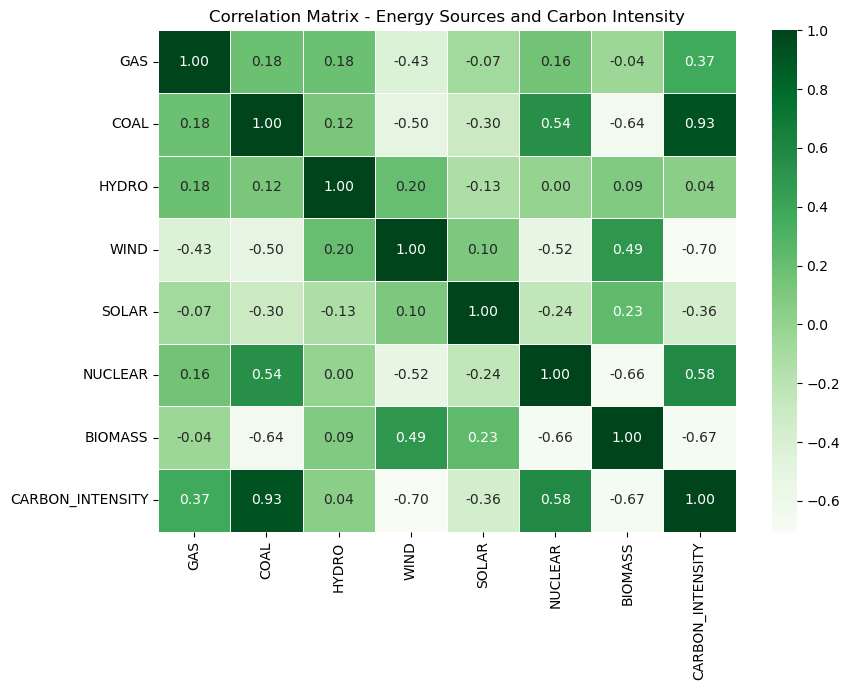

In [19]:
# Correlation matrix across input features and target
corr_df = df[["GAS", "COAL", "HYDRO", "WIND", "SOLAR", "NUCLEAR", "BIOMASS", "CARBON_INTENSITY"]]
carbon_corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(carbon_corr, annot=True, fmt=".2f", cmap="Greens", ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_title("Correlation Matrix - Energy Sources and Carbon Intensity")
plt.tight_layout()
plt.show()

A set of box plots gives us a sense of how each energy source differs across the three carbon classes, an important sanity check before modelling.

C:\Users\CharlesArthur\AppData\Local\Temp\ipykernel_15968\1432742867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig1 = sns.catplot(


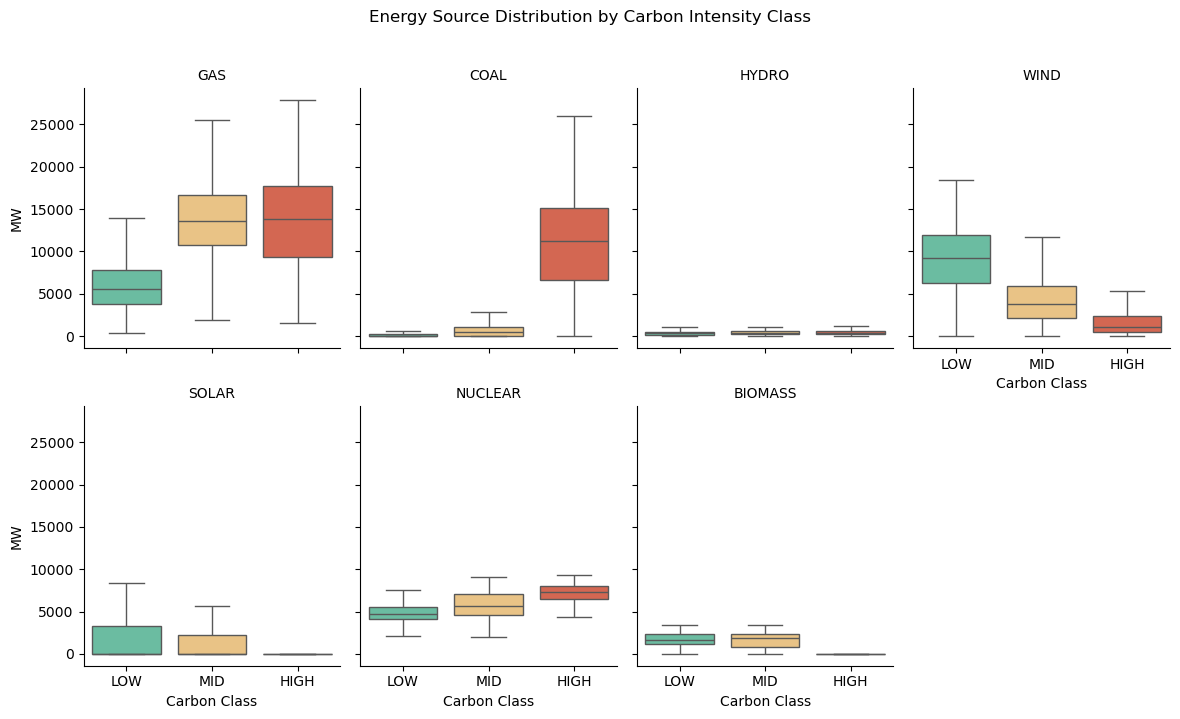

In [20]:
# Melt the dataframe for multi-variable box plot
features = ["GAS", "COAL", "HYDRO", "WIND", "SOLAR", "NUCLEAR", "BIOMASS"]
plot_df = df.melt(id_vars="CARBON_CLASS", value_vars=features)

fig1 = sns.catplot(
    x="CARBON_CLASS",
    y="value",
    col="variable",
    kind="box",
    data=plot_df,
    col_wrap=4,
    height=3.5,
    aspect=0.85,
    order=["LOW", "MID", "HIGH"],
    palette={"LOW": "#5DCAA5", "MID": "#FAC775", "HIGH": "#E8593C"},
    showfliers=False
)
fig1.set_titles(col_template="{col_name}")
fig1.set_axis_labels("Carbon Class", "MW")
fig1.figure.suptitle("Energy Source Distribution by Carbon Intensity Class", y=1.02)
plt.tight_layout()
plt.show()

---
### Building the Model
We split our data into training and test sets, define the features and target variable, and train the Decision Tree classifier. We start with `max_depth=5` to keep the tree interpretable while maintaining strong accuracy.

In [21]:
# Define features (X) and target (y)
features = ["GAS", "COAL", "HYDRO", "WIND", "SOLAR", "NUCLEAR", "BIOMASS"]
X = df[features]
y = df["CARBON_CLASS"]

# Split into train and test sets (75/25 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=25, stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")

Training rows: 228,827
Test rows:     76,276


In [22]:
# Train the Decision Tree classifier
# max_depth=5 balances interpretability with accuracy
dt_model = DecisionTreeClassifier(max_depth=5, random_state=25, class_weight="balanced")
dt_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


---
### Decision Tree Visualisation
We visualise the decision tree to understand how the model splits on feature values to reach each outcome. The colour of each node represents the dominant class at that split — green for LOW, orange for MID, red for HIGH.

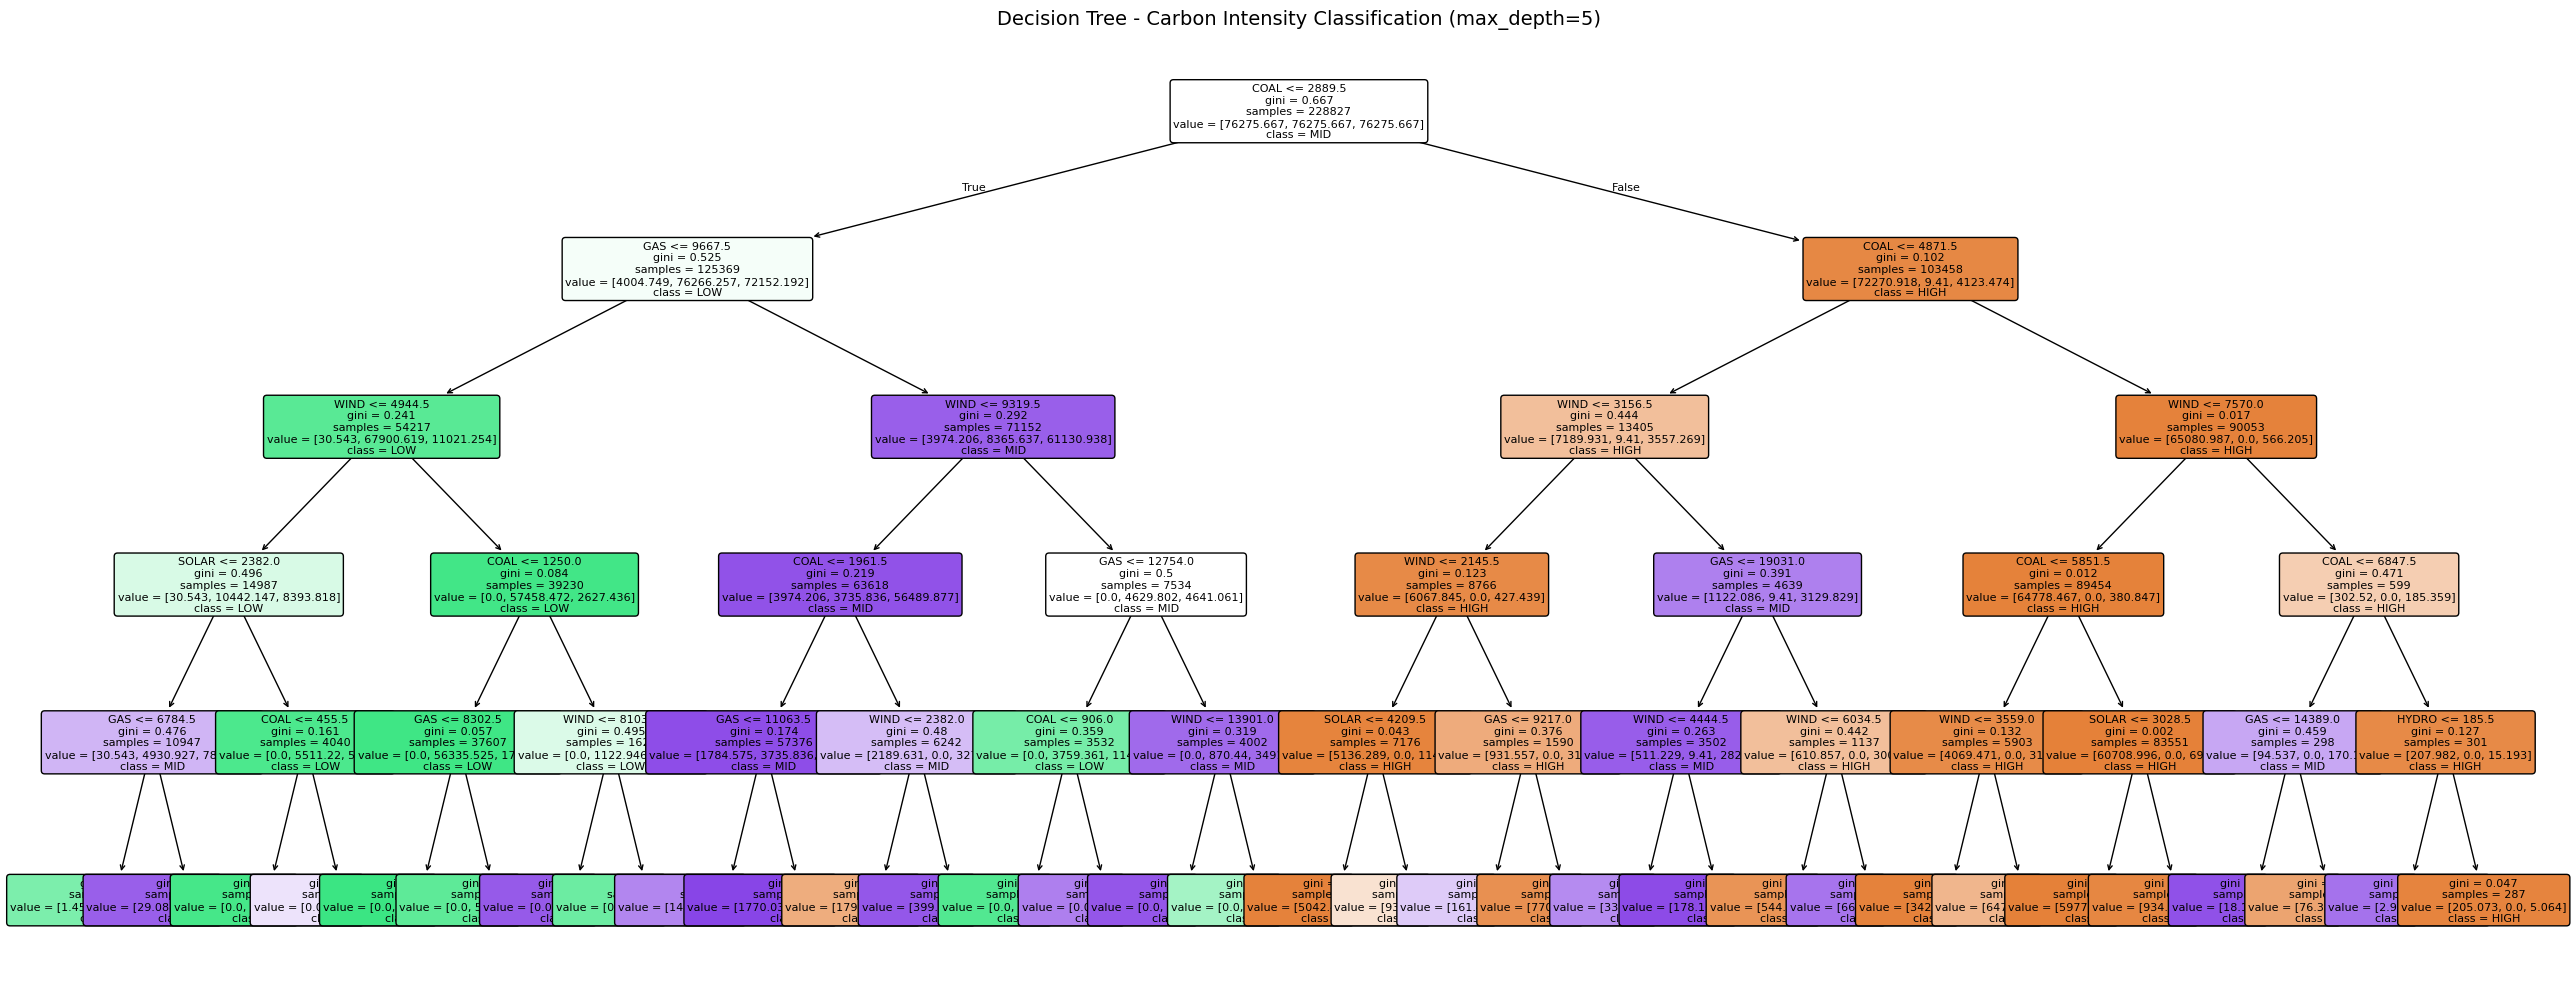

In [23]:
# Visualise the full decision tree (max_depth=5)
fig, ax = plt.subplots(figsize=(26, 10))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title("Decision Tree - Carbon Intensity Classification (max_depth=5)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Text representation of the top 3 decision levels
print(export_text(dt_model, feature_names=features, max_depth=3))

|--- COAL <= 2889.50
|   |--- GAS <= 9667.50
|   |   |--- WIND <= 4944.50
|   |   |   |--- SOLAR <= 2382.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- SOLAR >  2382.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- WIND >  4944.50
|   |   |   |--- COAL <= 1250.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- COAL >  1250.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- GAS >  9667.50
|   |   |--- WIND <= 9319.50
|   |   |   |--- COAL <= 1961.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- COAL >  1961.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- WIND >  9319.50
|   |   |   |--- GAS <= 12754.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- GAS >  12754.00
|   |   |   |   |--- truncated branch of depth 2
|--- COAL >  2889.50
|   |--- COAL <= 4871.50
|   |   |--- WIND <= 3156.50
|   |   |   |--- WIND <= 2145.50
|   |   |   |   |--- truncated branch of depth 2


---
### Feature Importance
Decision Trees provide a built-in feature importance score, indicating which input variables contributed most to reducing Gini impurity across all splits. A higher score means the model relies more heavily on that feature.

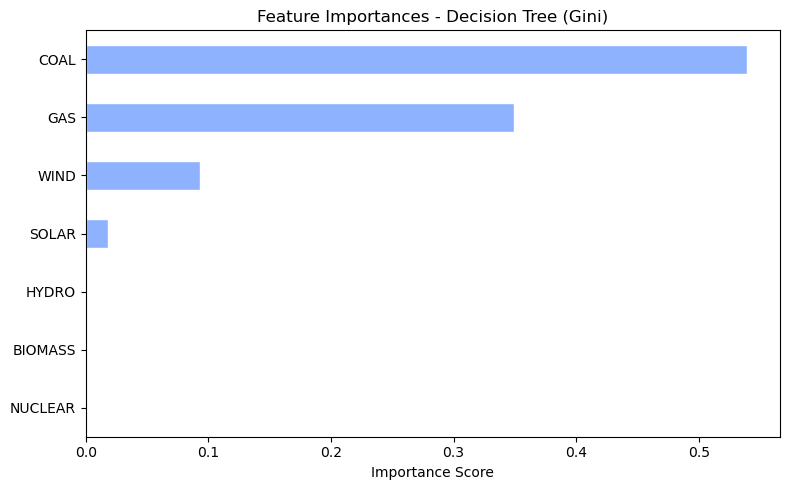


Feature Importances (ranked):
COAL       0.5394
GAS        0.3491
WIND       0.0933
SOLAR      0.0182
HYDRO      0.0001
NUCLEAR    0.0000
BIOMASS    0.0000
dtype: float64


In [25]:
# Extract and visualise feature importances
importances = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", color="#8FB2FF", edgecolor="white", ax=ax)
ax.set_title("Feature Importances - Decision Tree (Gini)")
ax.set_xlabel("Importance Score")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nFeature Importances (ranked):")
print(importances.sort_values(ascending=False).round(4))

---
### Communicating the Results
We evaluate model quality using a range of metrics. For a multi-class classifier we look at accuracy, per-class precision, recall and F1-score, a confusion matrix, and a ROC curve.

- **Accuracy**: Overall proportion of correct predictions
- **Precision**: Of all predictions for a class, how many were correct?
- **Recall**: Of all actual instances of a class, how many did we catch?
- **F1-Score**: Harmonic mean of precision and recall

In [26]:
# Generate predictions on the test set
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

Overall Accuracy: 94.15%


In [27]:
# Full classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred, target_names=dt_model.classes_))

              precision    recall  f1-score   support

        HIGH       0.99      0.96      0.97     34963
         LOW       0.91      0.92      0.92     16211
         MID       0.90      0.93      0.91     25102

    accuracy                           0.94     76276
   macro avg       0.93      0.94      0.93     76276
weighted avg       0.94      0.94      0.94     76276



The **Confusion Matrix** shows us where the model is making correct and incorrect predictions for each class.

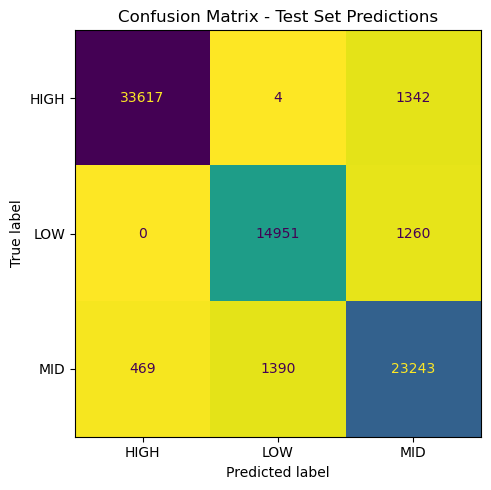

In [28]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)
disp.plot(cmap="viridis_r", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - Test Set Predictions")
plt.tight_layout()
plt.show()

In [30]:
# Summarise correct vs incorrect predictions
correct   = (y_test == y_pred).sum()
incorrect = (y_test != y_pred).sum()
total     = len(y_test)
print(f"Correct:   {correct:,}")
print(f"Incorrect: {incorrect:,}")
print(f"Total:     {total:,}")
print(f"Accuracy:  {correct / total * 100:.2f}%")

Correct:   71,811
Incorrect: 4,465
Total:     76,276
Accuracy:  94.15%


**ROC-AUC (One vs Rest)** extends the binary ROC curve to multi-class problems by treating each class as a binary outcome in turn. A score of 1.0 is perfect; 0.5 is no better than random chance.

Macro ROC-AUC (OvR): 0.9850


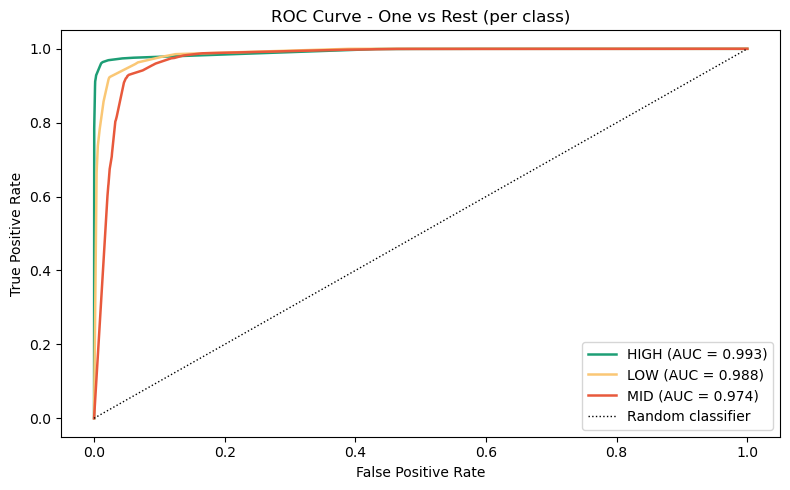

In [31]:
# Multi-class ROC AUC (One vs Rest)
y_test_bin = label_binarize(y_test, classes=dt_model.classes_)
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC (OvR): {roc_auc:.4f}")

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1D9E75", "#FAC775", "#E8593C"]

for i, (cls, color) in enumerate(zip(dt_model.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{cls} (AUC = {roc_auc_cls:.3f})")

ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - One vs Rest (per class)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### Depth Optimisation
To check whether `max_depth=5` is optimal, we test a range of depths and compare train vs test accuracy. This helps us identify where the model begins to overfit.

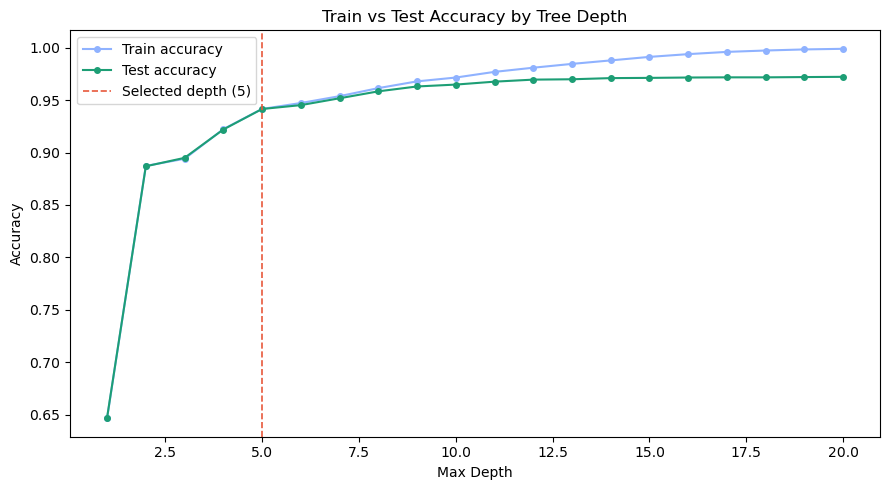

In [32]:
# Test accuracy across a range of tree depths
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=25, class_weight="balanced")
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_scores, label="Train accuracy", color="#8FB2FF", marker="o", markersize=4)
ax.plot(depths, test_scores, label="Test accuracy", color="#1D9E75", marker="o", markersize=4)
ax.axvline(x=5, color="#E8593C", linestyle="--", linewidth=1.2, label="Selected depth (5)")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy by Tree Depth")
ax.legend()
plt.tight_layout()
plt.show()

---
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production-level servers, produce technical documentation and build this into your BAU process.

The trained model can be exported using `joblib` or `pickle`, enabling it to be loaded into a production pipeline where live grid generation mix data is fed in to classify the likely carbon intensity outcome in near real time.

---
### Stretch Tasks

By this stage you have completed everything required. The following stretch tasks go further:
- Aggregate mean energy source values per carbon class to validate feature intuition
- Experiment with `min_samples_leaf` or `min_samples_split` constraints
- Try a Random Forest ensemble for a performance comparison
- Use `StratifiedKFold` cross-validation for a more robust accuracy estimate

In [33]:
# Mean energy source values by carbon class
features = ["GAS", "COAL", "HYDRO", "WIND", "SOLAR", "NUCLEAR", "BIOMASS"]
df.groupby("CARBON_CLASS")[features].mean().round(1)

,GAS,COAL,HYDRO,WIND,SOLAR,NUCLEAR,BIOMASS
CARBON_CLASS,,,,,,,
HIGH,13441.6,11187.1,402.9,1637.1,268.5,7208.0,122.0
LOW,5998.1,148.5,373.7,9176.5,1903.4,4872.4,1747.5
MID,13713.9,796.5,399.3,4312.7,1339.9,5781.4,1645.2


In [34]:
# Optional: Random Forest comparison with cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=25,
                             class_weight="balanced", n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Random Forest 5-fold CV Accuracy: {cv_scores.mean()*100:.2f}% (+-{cv_scores.std()*100:.2f}%)")

Random Forest 5-fold CV Accuracy: 87.97% (+-9.50%)
